In [1]:
import pandas as pd
import numpy as np
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [2]:
df = pd.read_csv("../data/processed/datas_cleaned.csv")
df["item_id"] = df["region"] + "_" + df["size_rank"].astype(str)
df["timestamp"] = pd.to_datetime((df["year"] - 543).astype(str))

ts_df = TimeSeriesDataFrame.from_data_frame(
    df[["item_id", "timestamp", "value", "tourists_mn"]],
    id_column="item_id",
    timestamp_column="timestamp",
)

In [3]:
train_data = ts_df.loc[ts_df.index.get_level_values("timestamp") <= "2011-01-01"]

In [4]:
save_path_backtest = "../AutogluonModels/TimeSeriesPredictor_Backtest"
predictor_backtest = TimeSeriesPredictor(
    prediction_length=2,
    target="value",
    eval_metric="MASE",
    known_covariates_names=["tourists_mn"],
    path=save_path_backtest,
).fit(train_data, presets="best_quality", time_limit=600)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to 'd:\Mini Project\Term Project\AutogluonModels\TimeSeriesPredictor_Backtest'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.10
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          20
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       2.08 GB / 15.73 GB (13.2%)
Disk Space Avail:   635.34 GB / 953.85 GB (66.6%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': ['tourists_mn'],
 'num_val_windows': 'auto',
 'prediction_length': 2,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 

In [5]:
predictor_backtest.evaluate(train_data)

Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


{'MASE': -18.817317568805176}

In [6]:
predictor_backtest.leaderboard()

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-18.817318,0.046999,0.219000,11
1,Chronos2SmallFineTuned,-18.817318,0.046999,88.301197,6
2,DeepAR,-19.280614,0.049649,49.674488,10
3,RecursiveTabular,-19.743604,0.039000,0.207999,2
4,Chronos2,-19.827546,0.562875,19.150098,5
5,DynamicOptimizedTheta,-19.916409,3.044927,0.010999,4
6,TemporalFusionTransformer,-19.974098,0.115000,144.491727,9
7,SeasonalNaive,-20.090303,7.080522,0.013377,1
8,AutoETS,-20.090303,0.029664,0.015001,7
9,ChronosWithRegressor[bolt_small],-20.192384,1.570104,0.506766,8


In [7]:
future_covariates = ts_df.loc[
    ts_df.index.get_level_values("timestamp") > "2011-01-01", ["tourists_mn"]
]

In [8]:
predictions = predictor_backtest.predict(train_data, known_covariates=future_covariates)
predictions

Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


mean           0.1           0.2  \
item_id        timestamp                                              
Bangkok_1      2013-01-01  3.432449e+09  9.182499e+08  1.711543e+09   
               2015-01-01  3.773312e+09  6.964420e+08  1.536124e+09   
Bangkok_2      2013-01-01  8.312591e+09  3.488753e+09  5.002873e+09   
               2015-01-01  8.923281e+09  3.278437e+09  4.915060e+09   
Bangkok_3      2013-01-01  3.354275e+10  2.288895e+10  2.689303e+10   
               2015-01-01  3.501469e+10  2.289169e+10  2.711265e+10   
Central_1      2013-01-01  1.670221e+10  6.349729e+09  9.679572e+09   
               2015-01-01  1.777011e+10  5.886419e+09  9.446430e+09   
Central_2      2013-01-01  1.153793e+10  5.824373e+09  7.765303e+09   
               2015-01-01  1.220110e+10  5.801744e+09  7.938355e+09   
Central_3      2013-01-01  2.177637e+10  1.213719e+10  1.543817e+10   
               2015-01-01  2.302804e+10  1.215787e+10  1.577655e+10   
Northern_1     2013-01-01  9.275877e+09  3.096512e+09  5.088680e+09   
               2015-01-01  1.002239e+10  2.653594e+09  4.748962e+09   
Northern_2     2013-01-01  6.242154e+09  2.662328e+09  3.805343e+09   
               2015-01-01  6.632662e+09  2.416942e+09  3.635985e+09   
Northern_3     2013-01-01  6.685605e+09  2.664074e+09  3.751970e+09   
               2015-01-01  6.946321e+09  2.574098e+09  3.815099e+09   
Northeastern_1 2013-01-01  5.027996e+09  2.054174e+09  3.015876e+09   
               2015-01-01  5.321501e+09  1.972592e+09  2.999659e+09   
Northeastern_2 2013-01-01  4.115817e+09  2.035832e+09  2.720955e+09   
               2015-01-01  4.340806e+09  1.894160e+09  2.639721e+09   
Northeastern_3 2013-01-01  4.692311e+09  2.226456e+09  3.142389e+09   
               2015-01-01  5.059993e+09  2.158619e+09  3.136664e+09   
Southern_1     2013-01-01  3.863056e+10  1.252320e+10  2.097546e+10   
               2015-01-01  4.177983e+10  1.069168e+10  1.957462e+10   
Southern_2     2013-01-01  1.842274e+10  9.152059e+09  1.211212e+10   
               2015-01-01  1.959842e+10  9.194291e+09  1.241223e+10   
Southern_3     2013-01-01  2.960245e+10  1.518569e+10  2.045808e+10   
               2015-01-01  3.086458e+10  1.491590e+10  2.036164e+10   

                                    0.3           0.4           0.5  \
item_id        timestamp                                              
Bangkok_1      2013-01-01  2.324279e+09  2.851940e+09  3.432449e+09   
               2015-01-01  2.344269e+09  3.093911e+09  3.773312e+09   
Bangkok_2      2013-01-01  6.191604e+09  7.223380e+09  8.312591e+09   
               2015-01-01  6.385786e+09  7.738169e+09  8.923281e+09   
Bangkok_3      2013-01-01  2.924336e+10  3.130018e+10  3.354275e+10   
               2015-01-01  2.977091e+10  3.228375e+10  3.501469e+10   
Central_1      2013-01-01  1.222026e+10  1.440929e+10  1.670221e+10   
               2015-01-01  1.251840e+10  1.532627e+10  1.777011e+10   
Central_2      2013-01-01  9.120725e+09  1.029906e+10  1.153793e+10   
               2015-01-01  9.475730e+09  1.089320e+10  1.220110e+10   
Central_3      2013-01-01  1.776316e+10  1.974322e+10  2.177637e+10   
               2015-01-01  1.840026e+10  2.081355e+10  2.302804e+10   
Northern_1     2013-01-01  6.608439e+09  7.902690e+09  9.275877e+09   
               2015-01-01  6.712614e+09  8.507881e+09  1.002239e+10   
Northern_2     2013-01-01  4.690237e+09  5.448282e+09  6.242154e+09   
               2015-01-01  4.752991e+09  5.770036e+09  6.632662e+09   
Northern_3     2013-01-01  4.677088e+09  5.651494e+09  6.685605e+09   
               2015-01-01  4.858997e+09  5.929982e+09  6.946321e+09   
Northeastern_1 2013-01-01  3.740488e+09  4.368616e+09  5.027996e+09   
               2015-01-01  3.846328e+09  4.626473e+09  5.321501e+09   
Northeastern_2 2013-01-01  3.244051e+09  3.684288e+09  4.115817e+09   
               2015-01-01  3.272454e+09  3.850853e+09  4.340806e+09   
Northeastern_3 2013-01-01  3.746413e+09  4.223062e+09  4.6

In [9]:
actual_values = ts_df.loc[
    ts_df.index.get_level_values("timestamp") > "2011-01-01", ["value"]
]
actual_values = actual_values.rename(columns={"value": "actual_value"})
comparison = predictions.join(actual_values).reset_index()
comparison["year_th"] = comparison["timestamp"].dt.year + 543
comparison = comparison[["item_id", "year_th", "actual_value", "mean", "0.1", "0.9"]]
comparison["error_%"] = (
    abs(comparison["mean"] - comparison["actual_value"]) / comparison["actual_value"]
) * 100
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
display(comparison)

,item_id,year_th,actual_value,mean,0.1,0.9,error_%
0,Bangkok_1,2556,"2,158,830,400","3,432,449,280","918,249,856","9,920,408,576",59
1,Bangkok_1,2558,"2,785,766,400","3,773,312,256","696,441,984","10,537,808,896",35
2,Bangkok_2,2556,"6,620,012,700","8,312,591,360","3,488,752,640","19,964,186,624",26
3,Bangkok_2,2558,"16,872,941,700","8,923,281,408","3,278,437,376","21,491,099,648",47
4,Bangkok_3,2556,"39,595,939,200","33,542,752,256","22,888,951,808","55,504,764,928",15
5,Bangkok_3,2558,"42,655,137,500","35,014,688,768","22,891,692,032","58,786,934,784",18
6,Central_1,2556,"5,983,787,200","16,702,214,144","6,349,729,280","40,642,359,296",179
7,Central_1,2558,"6,678,685,800","17,770,110,976","5,886,419,456","43,469,934,592",166
8,Central_2,2556,"7,205,202,200","11,537,933,312","5,824,372,736","22,491,623,424",60
9,Central_2,2558,"7,613,535,400","12,201,097,216","5,801,743,872","24,058,730,496",60


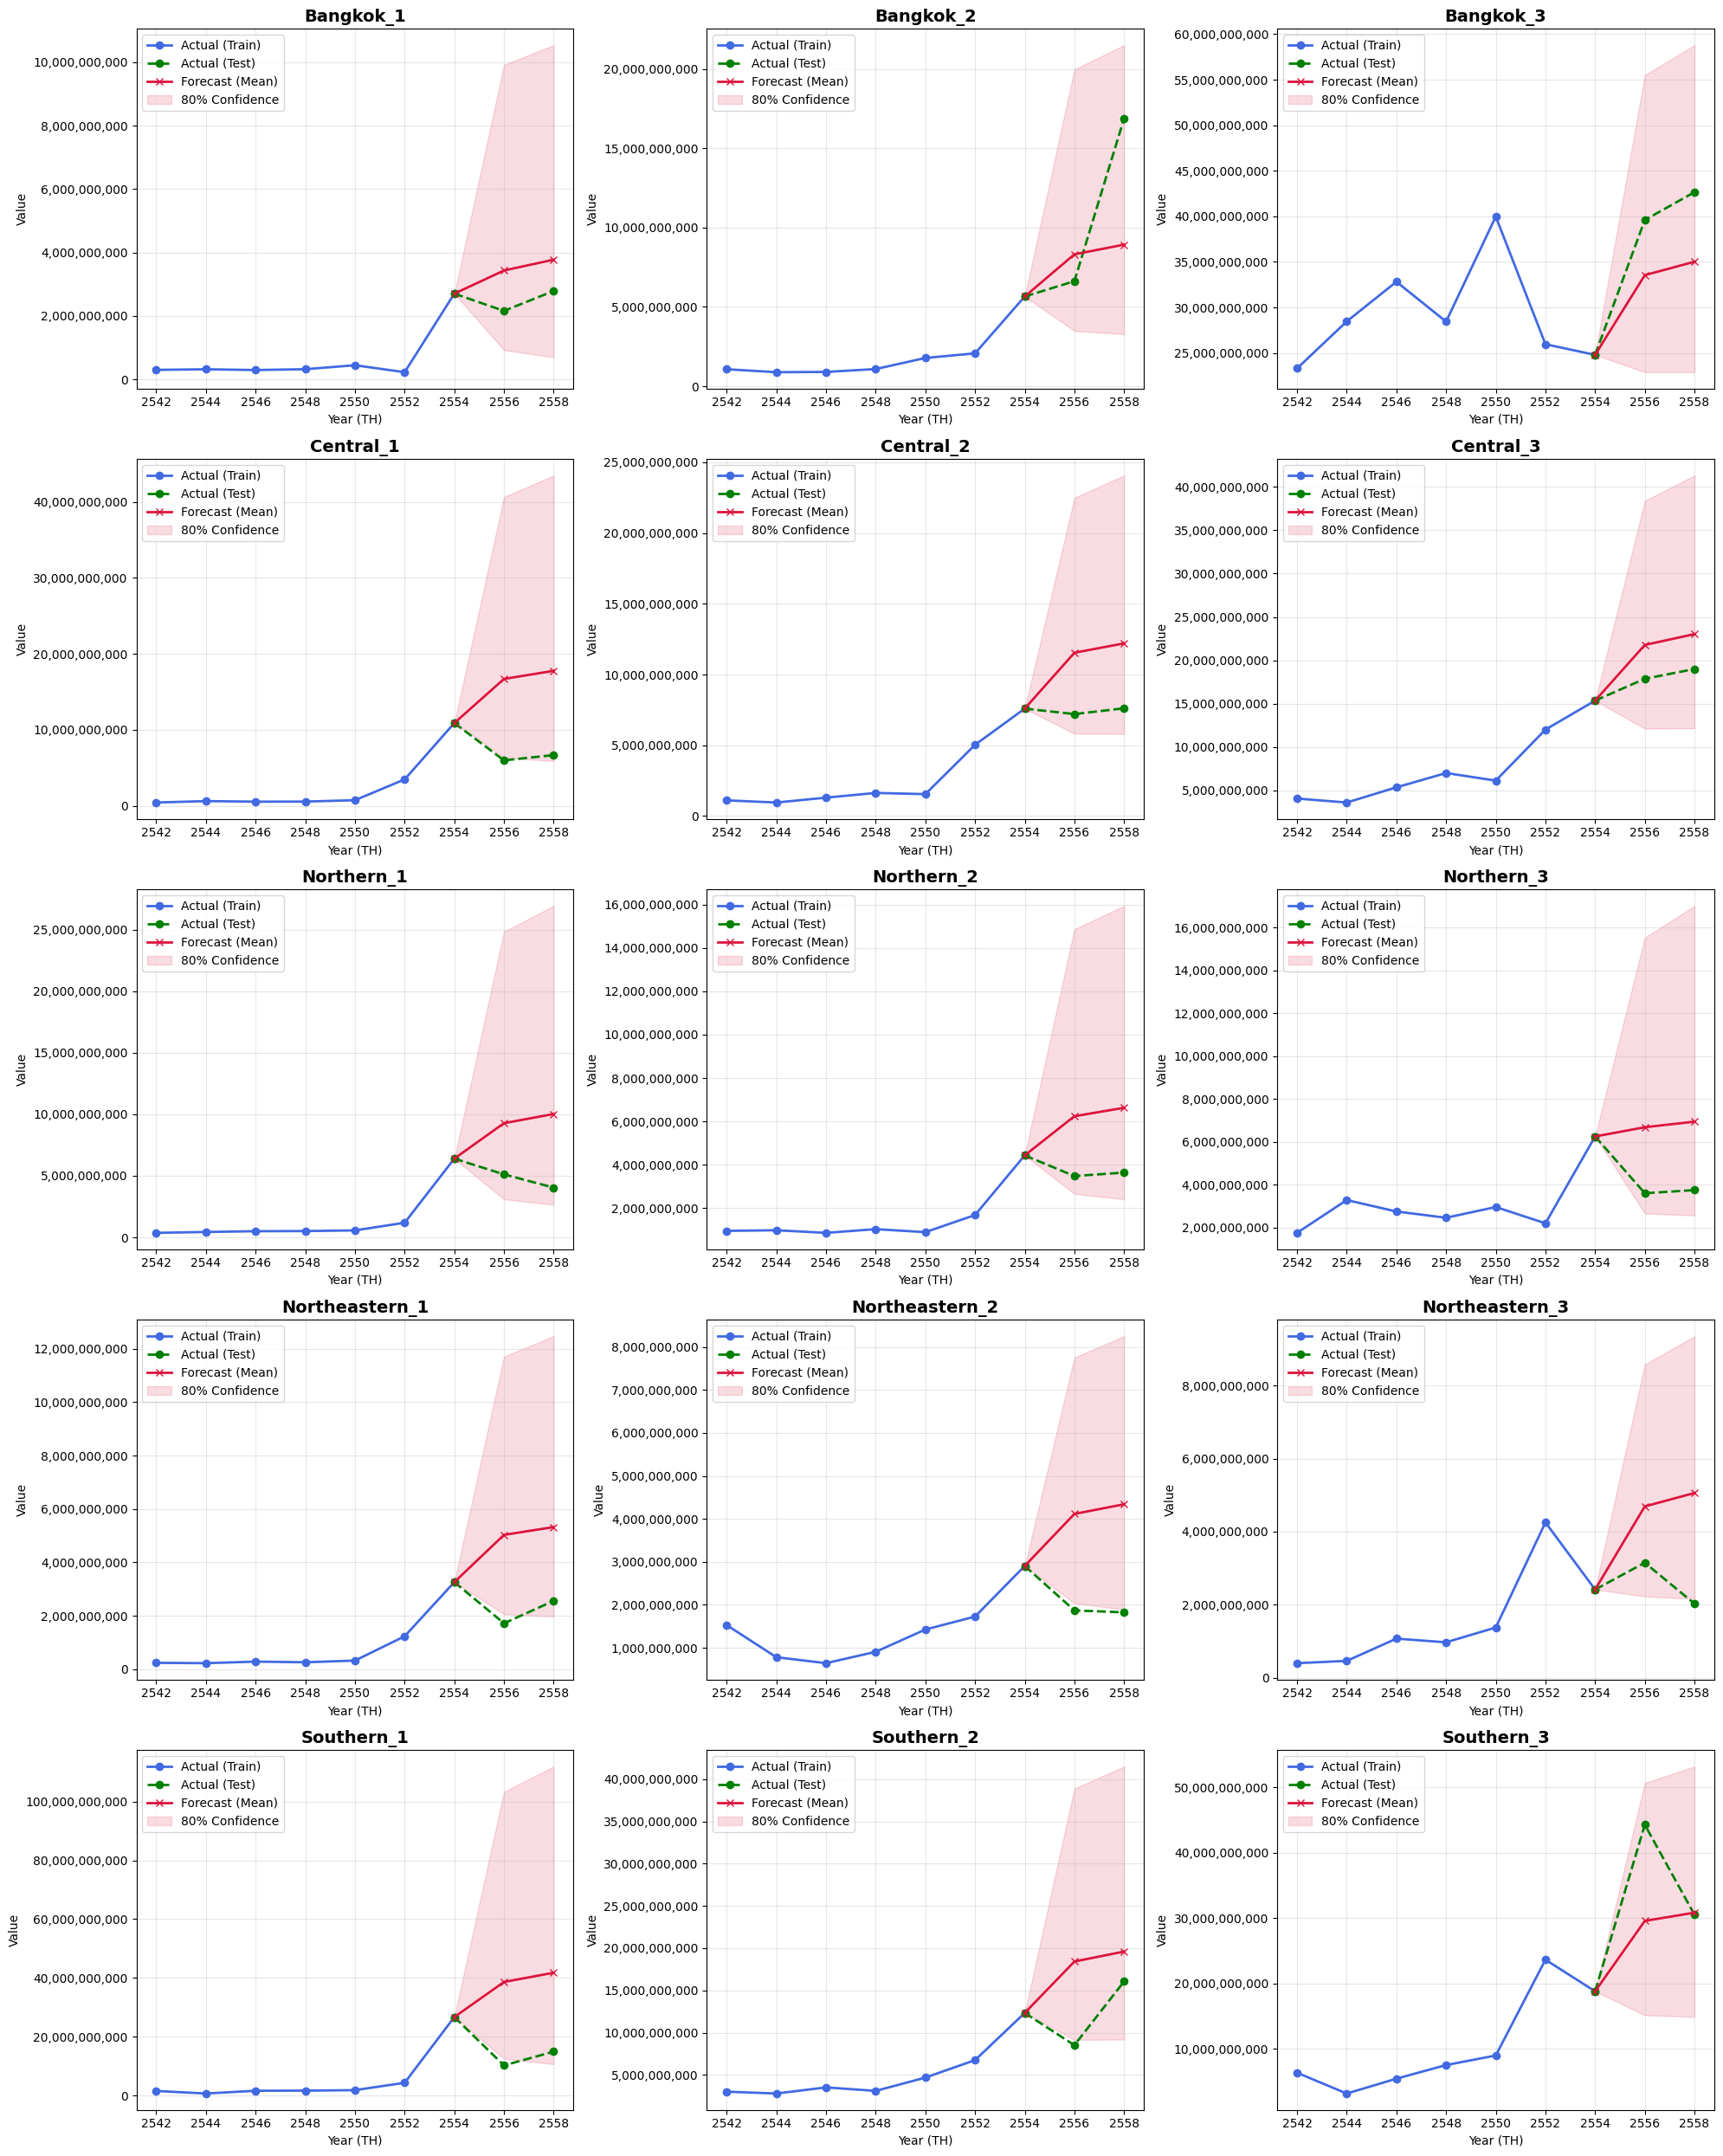

In [10]:
import matplotlib.pyplot as plt

# ดึงชื่อ item_id ทั้งหมด (15 กลุ่ม)
items = comparison["item_id"].unique()

# ตั้งค่าขนาดกราฟรวม (กว้าง 20, สูง 25 นิ้ว) เพื่อให้กราฟ 15 รูปดูไม่อึดอัด
plt.figure(figsize=(20, 25))

# วนลูปวาดกราฟทีละภูมิภาค
for i, item in enumerate(items, 1):
    plt.subplot(5, 3, i)  # สร้าง Grid 5 แถว 3 คอลัมน์

    # 1. ดึงข้อมูลอดีตของ item นี้จาก ts_df
    past = ts_df.loc[item].reset_index()
    past["year_th"] = past["timestamp"].dt.year + 543

    # 2. ดึงข้อมูลพยากรณ์ของ item นี้จากตาราง comparison
    pred = comparison[comparison["item_id"] == item]

    # แบ่งช่วงเวลาของของจริง (Actual)
    past_train = past[past["year_th"] <= 2554]  # อดีตที่โมเดลใช้เรียนรู้
    past_test = past[
        past["year_th"] >= 2554
    ]  # อนาคตที่เอาไว้ทดสอบ (เริ่มจาก 2554 เพื่อให้เส้นเชื่อมกัน)

    # พล็อตเส้นข้อมูลจริง (Actual)
    plt.plot(
        past_train["year_th"],
        past_train["value"],
        marker="o",
        label="Actual (Train)",
        color="royalblue",
        linewidth=2,
    )
    plt.plot(
        past_test["year_th"],
        past_test["value"],
        marker="o",
        linestyle="--",
        label="Actual (Test)",
        color="green",
        linewidth=2,
    )

    # 3. พล็อตเส้นพยากรณ์ (Forecast)
    # ดึงจุดสุดท้ายของปี 2554 มาเป็นจุดเชื่อมกราฟพยากรณ์
    last_train_year = past_train["year_th"].iloc[-1]
    last_train_val = past_train["value"].iloc[-1]

    pred_years = [last_train_year] + pred["year_th"].tolist()
    pred_means = [last_train_val] + pred["mean"].tolist()
    pred_lower = [last_train_val] + pred["0.1"].tolist()
    pred_upper = [last_train_val] + pred["0.9"].tolist()

    # วาดเส้นค่าเฉลี่ยที่ทายได้ และระบายสีช่วงความมั่นใจ 0.1 - 0.9 (80% Confidence Interval)
    plt.plot(
        pred_years,
        pred_means,
        marker="x",
        linestyle="-",
        label="Forecast (Mean)",
        color="crimson",
        linewidth=2,
    )
    plt.fill_between(
        pred_years,
        pred_lower,
        pred_upper,
        color="crimson",
        alpha=0.15,
        label="80% Confidence",
    )

    # ตกแต่งกราฟให้สวยงาม
    plt.title(f"{item}", fontsize=14, fontweight="bold")
    plt.xlabel("Year (TH)")
    plt.ylabel("Value")

    # ใส่ลูกน้ำที่แกน Y ให้ตัวเลขอ่านง่าย
    plt.gca().yaxis.set_major_formatter(
        plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
    )
    plt.grid(True, alpha=0.3)

    # โชว์ป้ายกำกับ (Legend) แค่รูปแรกก็พอจะได้ไม่รก
    plt.legend()

plt.tight_layout()
plt.show()

Loading predictor from path d:\Mini Project\Term Project\AutogluonModels\TimeSeriesPredictor_Backtest
Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


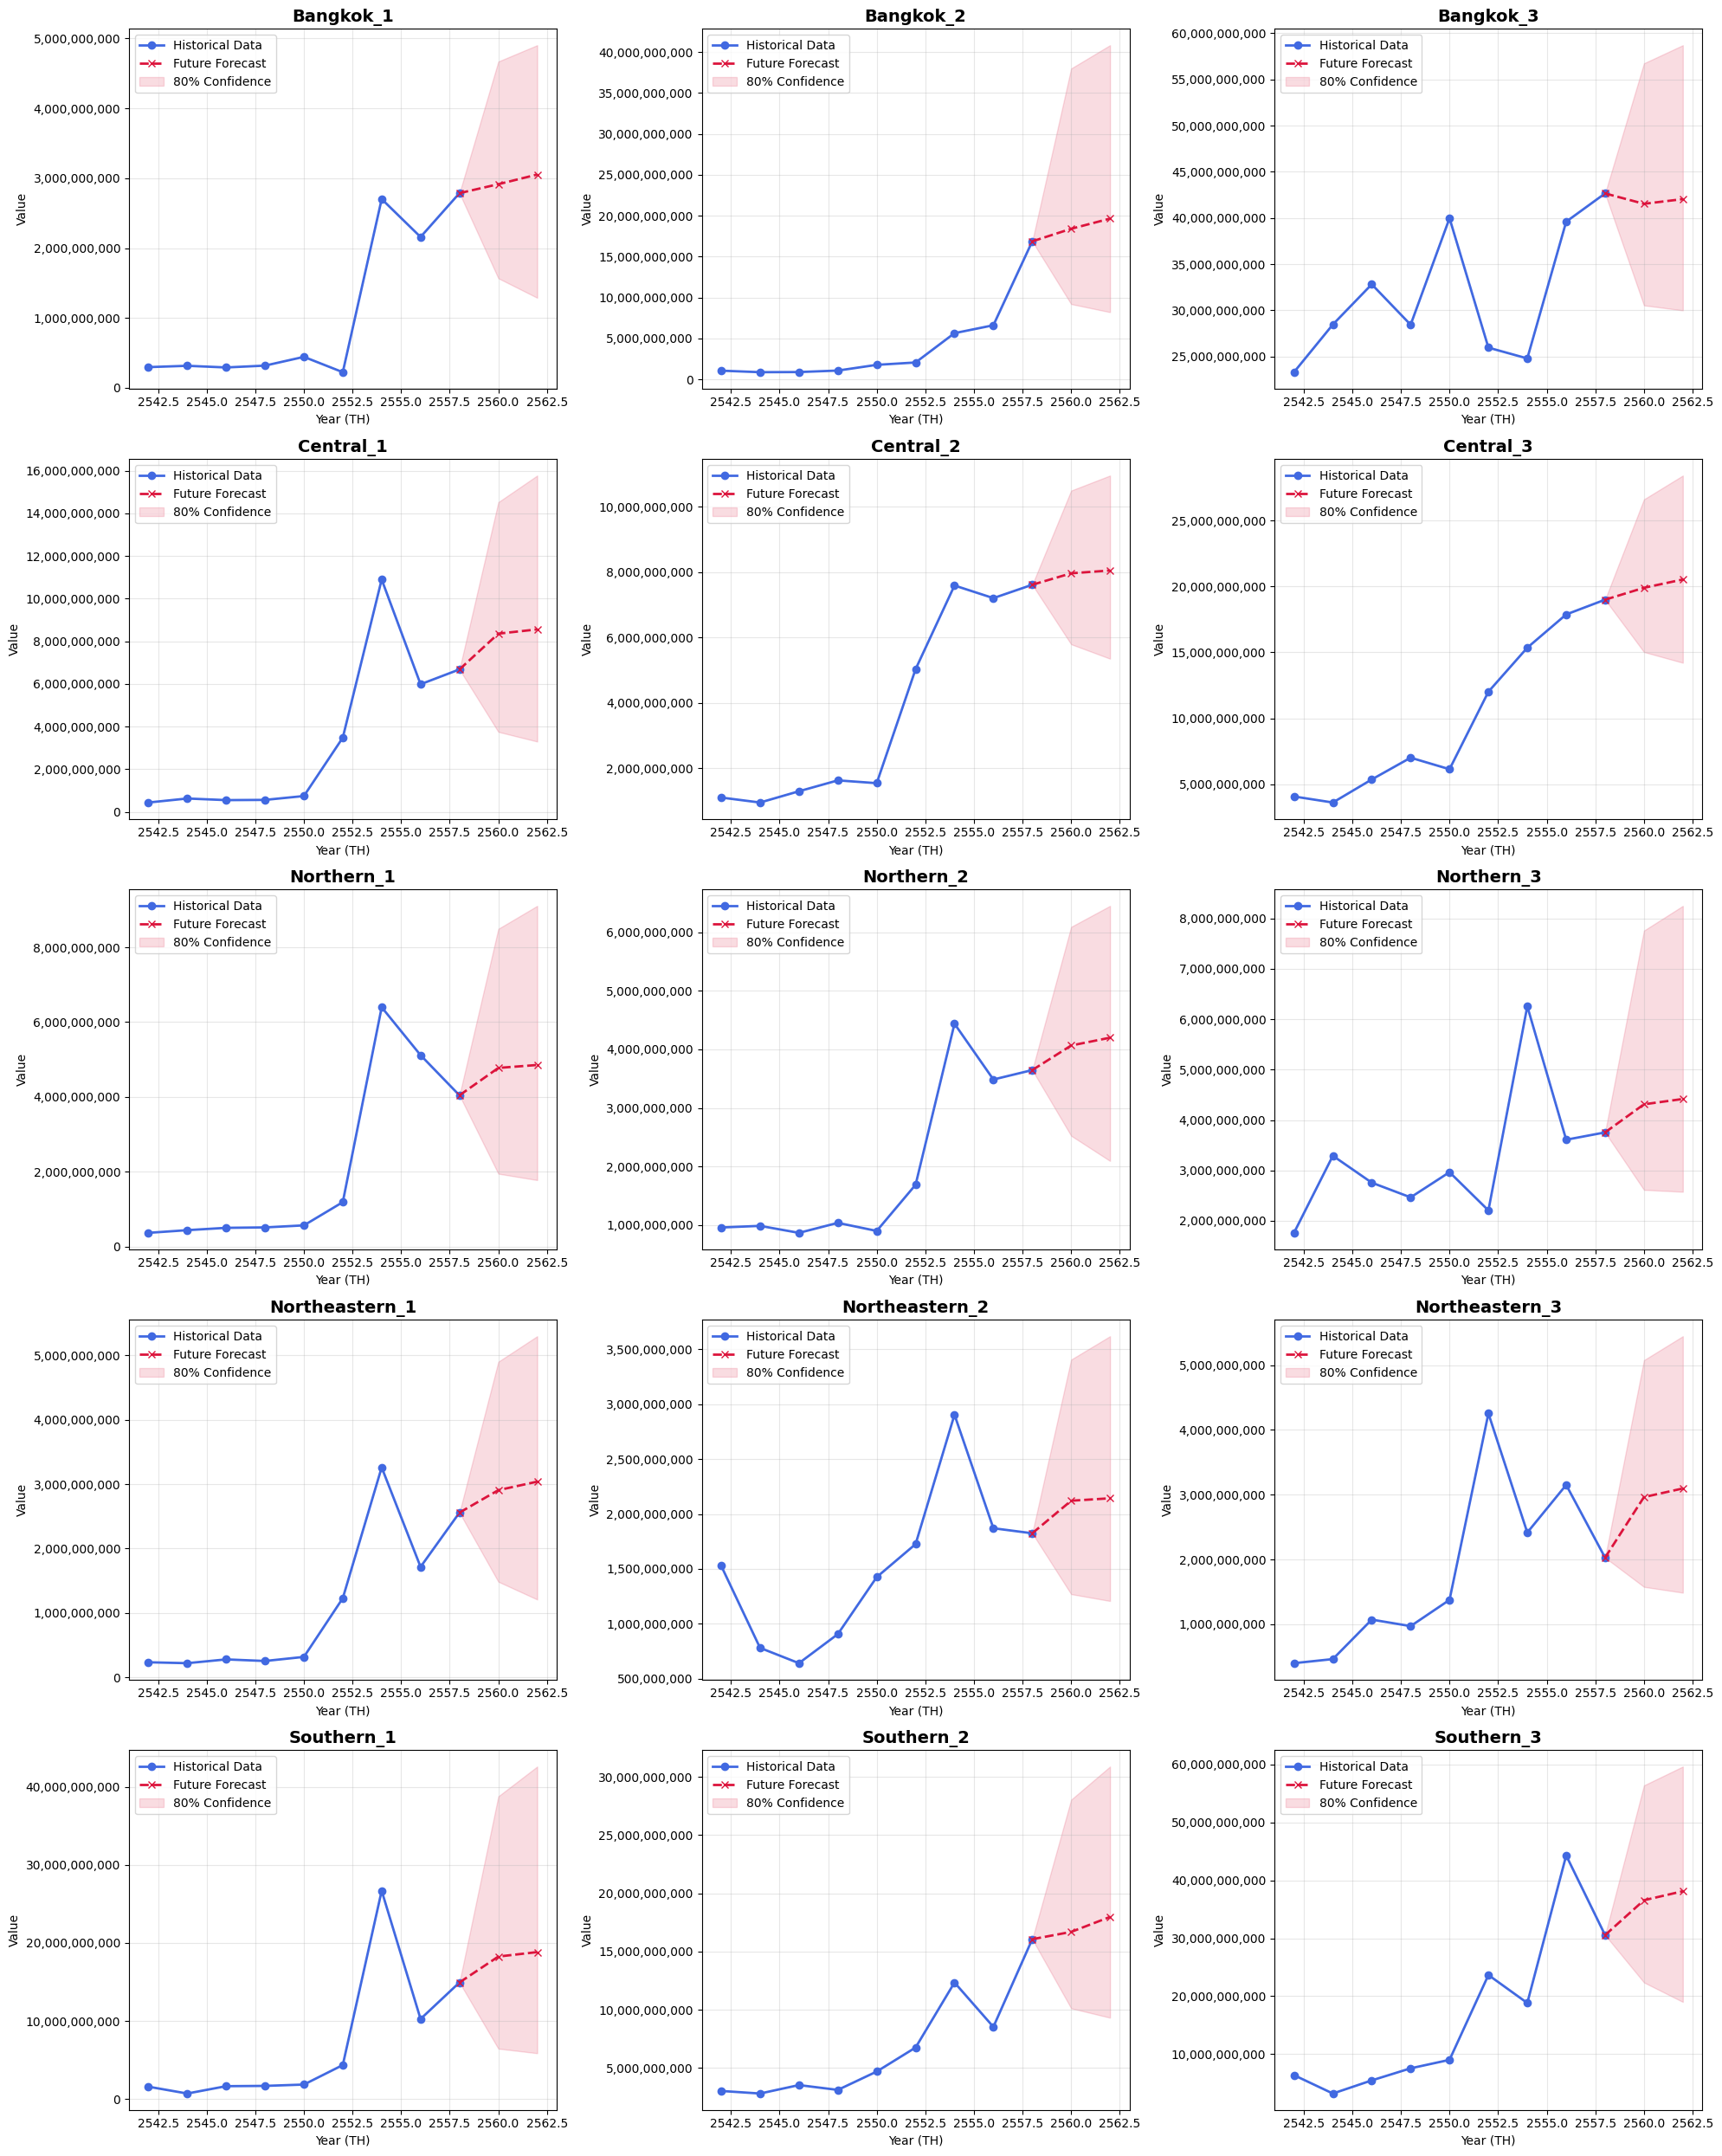

In [11]:
# 1. โหลดโมเดล "ตัวเต็ม" ที่เทรนด้วยข้อมูลทั้งหมดถึงปี 2558 กลับมา
predictor_full = TimeSeriesPredictor.load(
    "../AutogluonModels/TimeSeriesPredictor_Backtest/"
)

# 2. จำลองยอดนักท่องเที่ยว (Covariates) สำหรับปี 2017 และ 2019 (ที่คุณเคยเขียนไว้)
future_data = []
for item_id in ts_df.item_ids:
    last_date = ts_df.loc[item_id].index.max()
    future_dates = pd.date_range(start=last_date, periods=3, freq="2YS-JAN")[1:]
    region = item_id.split("_")[0]

    for date in future_dates:
        base = 35.0  # สมมติยอดนักท่องเที่ยวรวม 35 ล้านคน
        share = {
            "Bangkok": 0.35,
            "Southern": 0.25,
            "Central": 0.15,
            "Northern": 0.15,
            "Northeastern": 0.10,
        }
        tourists_million = (base * share.get(region, 0.1)) + np.random.uniform(
            -0.5, 0.5
        )
        future_tourists = int(max(0.1, tourists_million) * 1000000)

        future_data.append(
            {"item_id": item_id, "timestamp": date, "tourists_mn": future_tourists}
        )

future_covariates = TimeSeriesDataFrame.from_data_frame(
    pd.DataFrame(future_data), id_column="item_id", timestamp_column="timestamp"
)

# 3. สั่งพยากรณ์อนาคต (ปี 2560 และ 2562)
future_predictions = predictor_full.predict(ts_df, known_covariates=future_covariates)
future_predictions = future_predictions.reset_index()
future_predictions["year_th"] = future_predictions["timestamp"].dt.year + 543

# ---------------------------------------------------------
# 4. พล็อตกราฟดูหน้าตาอนาคตที่เราทำนายได้!
# ---------------------------------------------------------
items = ts_df.item_ids
plt.figure(figsize=(20, 25))

for i, item in enumerate(items, 1):
    plt.subplot(5, 3, i)

    # ข้อมูลอดีต
    past = ts_df.loc[item].reset_index()
    past["year_th"] = past["timestamp"].dt.year + 543

    # ข้อมูลพยากรณ์อนาคต
    pred = future_predictions[future_predictions["item_id"] == item]

    # พล็อตอดีต (เส้นสีน้ำเงิน)
    plt.plot(
        past["year_th"],
        past["value"],
        marker="o",
        label="Historical Data",
        color="royalblue",
        linewidth=2,
    )

    # จุดเชื่อมต่อระหว่างอดีตกับอนาคต
    last_year = past["year_th"].iloc[-1]
    last_val = past["value"].iloc[-1]

    pred_years = [last_year] + pred["year_th"].tolist()
    pred_means = [last_val] + pred["mean"].tolist()
    pred_lower = [last_val] + pred["0.1"].tolist()
    pred_upper = [last_val] + pred["0.9"].tolist()

    # พล็อตอนาคต (เส้นสีแดง + แถบความมั่นใจ)
    plt.plot(
        pred_years,
        pred_means,
        marker="x",
        linestyle="--",
        label="Future Forecast",
        color="crimson",
        linewidth=2,
    )
    plt.fill_between(
        pred_years,
        pred_lower,
        pred_upper,
        color="crimson",
        alpha=0.15,
        label="80% Confidence",
    )

    plt.title(f"{item}", fontsize=14, fontweight="bold")
    plt.xlabel("Year (TH)")
    plt.ylabel("Value")
    plt.gca().yaxis.set_major_formatter(
        plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
    )
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()